# Проект. Исследование стартапов

- Автор: Кривенко Виктория 
- Дата: 03.07.2026

## Введение

В рамках проекта проводится исследование рынка венчурных инвестиций на основе исторических данных о стартапах, объёмах и типах привлечённого финансирования, а также информации о возврате инвестиций. Анализ позволит выявить основные закономерности финансирования компаний, определить наиболее востребованные инвестиционные инструменты и оценить их эффективность.

**Цель проекта** - подготовить данные к анализу, исследовать структуру и динамику финансирования стартапов, определить особенности различных типов инвестиций и сформулировать рекомендации по выбору наиболее перспективных направлений инвестирования, исходя из ситуации на рынке по состоянию на 2015 год.



## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузим необходимые для работы библиотеки и данные по проекту

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Основной датасет
investments = pd.read_csv(
    'https://code.s3.yandex.net/datasets/cb_investments.zip',
    sep=';',
    low_memory=False)

# Дополнительный датасет
returns = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

- Познакомимся с данными датасета `cb_investments` - выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Датасет `cb_investments` содержит 54 294 записи и 40 столбцов. В данных представлены как количественные признаки (объём инвестиций, количество раундов финансирования и суммы по различным типам инвестиций), так и категориальные признаки (название компании, отрасль, страна, регион и другие).

В датафрейме присутствуют пропуски. Наибольшее их количество наблюдается в столбцах, содержащих информацию о местоположении компаний (`state_code`, `city`), датах основания (`founded_at`, `founded_month`, `founded_quarter`), количестве участников финансирования (`participants`) и среднем по времени раунде финансирования (`mid_funding_at`). Также имеются пропуски в столбцах `name`, `homepage_url`, `category_list`, `market`, `status и country_code`.

Большинство числовых столбцов имеют тип float64, однако столбец `funding_total_usd`, содержащий общий объём привлечённых инвестиций, имеет тип object, хотя представляет собой числовые данные. Кроме того, столбцы с датами также имеют тип object и потребуют преобразования в формат даты.

На следующем этапе необходимо более подробно изучить пропуски, проверить данные на наличие дубликатов, а также привести типы данных к корректному виду для дальнейшего анализа.

- Познакомимся с данными датасета `cb_returns.csv` - выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [5]:
returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [6]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Датасет `cb_returns` содержит 15 записей и 14 столбцов. В нём представлена информация о годовых объёмах возврата средств по различным типам финансирования.

Пропуски в данных отсутствуют. Все столбцы имеют корректные типы данных: столбец `year` представлен целочисленным типом int64, а значения объёмов возврата - вещественным типом float64.

Таким образом, данный датасет не требует дополнительной предобработки и может быть использован в дальнейшем анализе без изменения структуры данных.

In [7]:
# Сохраняем количество строк перед обработкой
rows = len(investments)

### 1.2. Предобработка данных

Проверим названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведем их к единому аккуратному стилю.

In [8]:
# Выводим названия всех столбцов датафрейма, чтобы проверить их стиль написания
investments.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [9]:
# Приводим названия столбцов к единому стилю
investments.columns = investments.columns.str.strip()

# Проверяем названия всех столбцов
investments.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

- Уберем в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [10]:
# Проверяем значения столбца `funding_total_usd`
investments['funding_total_usd'].head()

0     9,00,00,000 
1       20,00,000 
2       90,00,000 
3       77,00,000 
4        5,40,000 
Name: funding_total_usd, dtype: object

In [11]:
# Убираем пробелы
investments['funding_total_usd'] = (
    investments['funding_total_usd']
    .str.strip()
)

# Убираем запятые
investments['funding_total_usd'] = (
    investments['funding_total_usd']
    .str.replace(',', '')
)

# Переводим в число
investments['funding_total_usd'] = pd.to_numeric(
    investments['funding_total_usd'],
    errors='coerce'
)

# Проверяем значения
investments['funding_total_usd'].head()

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
Name: funding_total_usd, dtype: float64

- Обработаем типы данных в столбцах, которые хранят значения даты и времени.

In [12]:
date_columns = [
    'founded_at',
    'first_funding_at',
    'mid_funding_at',
    'last_funding_at']

for col in date_columns:
    investments[col] = pd.to_datetime(investments[col], errors = 'coerce')
    
# Проверяем типы данных
investments.dtypes

name                            object
homepage_url                    object
category_list                   object
market                          object
funding_total_usd              float64
status                          object
country_code                    object
state_code                      object
region                          object
city                            object
funding_rounds                 float64
participants                   float64
founded_at              datetime64[ns]
founded_month                   object
founded_quarter                 object
founded_year                   float64
first_funding_at        datetime64[ns]
mid_funding_at          datetime64[ns]
last_funding_at         datetime64[ns]
seed                           float64
venture                        float64
equity_crowdfunding            float64
undisclosed                    float64
convertible_note               float64
debt_financing                 float64
angel                    

В ходе предобработки столбцы с датами были преобразованы к типу datetime.

Столбцы `founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at` приведены к формату datetime для дальнейшего анализа временных зависимостей.

Дополнительные столбцы `founded_month` и `founded_quarter` оставлены без изменений, так как информация в них дублируется и может быть восстановлена из основного столбца `founded_at`.

- В датасете `cb_returns` сделаем столбец `year` индексом всего датасета.

In [13]:
returns.set_index('year', inplace=True)
returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


- Обработаем текстовые данные.

In [14]:
text_cols = [
    'category_list',
    'market',
    'status',
    'country_code',
    'state_code',
    'region',
    'city']

investments[text_cols] = investments[text_cols].fillna('unknown')

Пропущенные значения в категориальных признаках (`category_list`, `market`, `status`, `country_code`, `state_code`, `region`, `city`) были заменены на заглушку 'unknown', так как они не являются критическими для строк и могут быть интерпретированы как отдельная категория.

Это позволило сохранить все наблюдения в датасете и обеспечить корректную работу с категориальными данными при дальнейшем анализе.

- Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. Избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [15]:
# Считаем количество полных дубликатов в датасете
investments.duplicated().sum()

4855

In [16]:
# Удаляем дубликаты
investments = investments.drop_duplicates()

In [17]:
# Удаляем строки без финансирования
investments = investments.dropna(subset=['funding_total_usd'])

# Проверяем количество пропусков в `funding_total_usd`
investments['funding_total_usd'].isna().sum()

0

В ходе предобработки были удалены полные дубликаты в данных, что позволило исключить повторяющиеся записи.

Также были удалены строки без информации о сумме привлечённого финансирования (`funding_total_usd`), так как они не содержат значимой информации для анализа инвестиционной активности.

В результате данные стали более чистыми и пригодными для дальнейшего исследования рынка венчурных инвестиций.

- Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.

In [18]:
mid_dates = (
    investments['first_funding_at'] +
    (investments['last_funding_at'] - investments['first_funding_at']) / 2
)

investments['mid_funding_at'] = investments['mid_funding_at'].fillna(mid_dates)

# Проверяем количество пропусков в столбце
investments['mid_funding_at'].isna().sum()

1

После заполнения пропусков в `mid_funding_at` остался 1 пропуск, поскольку для этой записи отсутствует одна или обе даты (`first_funding_at` или `last_funding_at`), поэтому вычислить середину интервала невозможно.

In [19]:
print(f'Исходный размер: {rows}')
print(f'После чистки: {len(investments)}')
print(f'Удалено строк: {rows - len(investments)}')
print(f'Отброшено: {(1 - len(investments)/rows)*100:.1f}%')

Исходный размер: 54294
После чистки: 40907
Удалено строк: 13387
Отброшено: 24.7%


После предобработки в датасете осталось 40 907 записей из первоначальных 54 294. Было отброшено 24,7% данных. Основная причина удаления записей - отсутствие информации об общем объёме привлечённого финансирования (`funding_total_usd`) или отсутствие полезной информации для дальнейшего анализа. 

Несмотря на сокращение объёма данных примерно на четверть, оставшийся датасет содержит более 40 тысяч наблюдений, что является достаточным объёмом для проведения анализа и получения обоснованных выводов о рынке венчурных инвестиций.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

In [20]:
# Разница между первым и последним финансированием
funding_period = (
    investments['last_funding_at'] -
    investments['first_funding_at'])

# Создаем столбец с группами
investments['funding_group']= 'Срок финансирования более года'

investments.loc[investments['funding_rounds'] == 1, 'funding_group'] = 'Единичное финансирование'

investments.loc[(investments['funding_rounds'] > 1) 
                & (funding_period <= pd.Timedelta(days=365)), 'funding_group'] = 'Срок финансирования до года'

# Проверяем
investments['funding_group'].value_counts()

Единичное финансирование          24113
Срок финансирования более года    12293
Срок финансирования до года        4501
Name: funding_group, dtype: int64

Визуализируем соотношение этих групп, создав два графика:

- По количеству компаний: какой процент от общего числа компаний относится к каждой из трёх групп.
- По объёму инвестиций: какую долю от общего объёма привлечённых средств получила каждая группа.

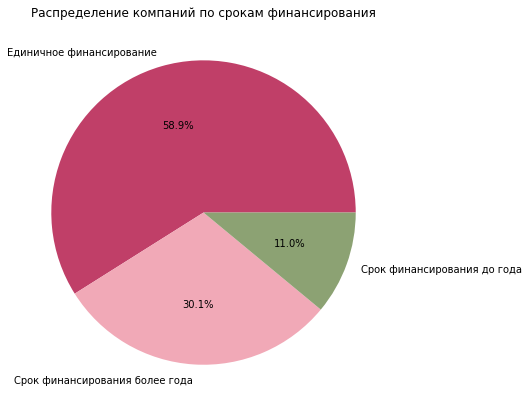

In [21]:
# Создадим рафик по количеству компаний
companies = (investments['funding_group'].value_counts(normalize=True) * 100)

colors = ['#C03F68', '#F1A9B7', '#8CA273']

plt.figure(figsize=(7,7))

plt.pie(companies, 
        labels =companies.index,
        autopct='%1.1f%%',
        colors =colors
)

plt.title('Распределение компаний по срокам финансирования')
plt.show()

Большинство компаний (58.9%) ограничиваются единичным раундом финансирования, что может указывать на высокую "пороговость" дальнейших инвестиций: значительная часть стартапов либо не демонстрирует достаточного роста, либо не переходит на следующие стадии привлечения капитала. 

Около трети компаний (30.1%) проходят более длительный цикл финансирования свыше года - это, как правило, более устойчивые или масштабируемые проекты, которые продолжают привлекать инвестиции на разных этапах развития.

Быстрый цикл финансирования до года встречается значительно реже (11%), что может говорить о том, что такие компании либо очень быстро достигают следующей стадии развития, либо столь же быстро прекращают активное привлечение средств. В целом распределение показывает, что рынок венчурных инвестиций сильно смещён в сторону либо однократных вложений, либо долгосрочного сопровождения ограниченного числа проектов.

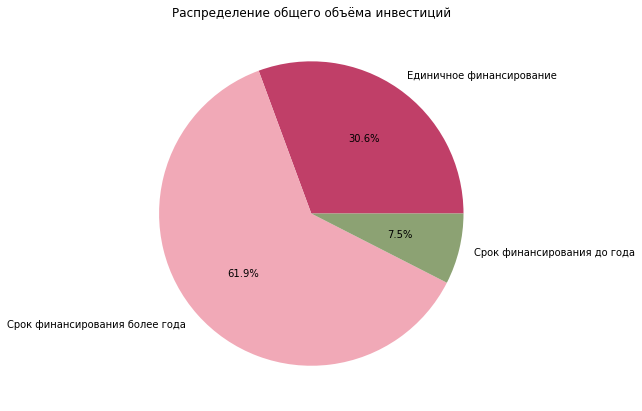

In [22]:
# График по объему инвестиций
funding = investments.groupby('funding_group')['funding_total_usd'].sum()

funding = funding / funding.sum() * 100

plt.figure(figsize=(7,7))
plt.pie(
    funding,
    labels=funding.index,
    autopct='%1.1f%%',
    colors=colors
)
plt.title('Распределение общего объёма инвестиций')
plt.show()

Основная часть привлечённых инвестиций приходится на компании со сроком финансирования более года - 61.9%, то есть именно стартапы, которые проходят через несколько раундов и развиваются на протяжении длительного времени, получают большую долю всех вложенных средств. Это говорит о том, что долгосрочные проекты и компании с устойчивым ростом являются наиболее привлекательными для инвесторов с точки зрения объёма вложений.

На единичное финансирование приходится 30.6% общего объёма инвестиций. Это заметная доля, что показывает: значительное количество денег всё же вкладывается в компании, которые получили только один раунд финансирования, однако такие проекты, вероятно, либо находятся на ранней стадии, либо не продолжают дальнейшее привлечение капитала.

Минимальная доля - 7.5% - приходится на компании с коротким циклом финансирования до года. Это означает, что относительно небольшая часть инвестиций распределяется между стартапами, которые быстро проходят весь цикл привлечения средств.

В целом можно сделать вывод, что основная концентрация капитала находится в долгосрочных инвестиционных проектах, тогда как краткосрочные и единичные раунды занимают меньшую долю рынка.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. 

In [23]:
# Посчитаем количество компаний в каждом сегменте рынка
investments['market'] = investments['market'].str.strip()
market_counts = investments['market'].value_counts()

# Проверим результат
market_counts.head(10)

Software               4812
Biotechnology          3590
unknown                2503
Mobile                 2344
E-Commerce             1866
Curated Web            1693
Enterprise Software    1381
Health Care            1185
Clean Technology       1180
Games                  1117
Name: market, dtype: int64

Наиболее распространённым сегментом рынка является Software - 4812 компаний, далее следуют Biotechnology (3590 компания), Mobile (2344 компании) и E-Commerce (1866 компаний). Кроме того, для 2503 компаний информация о сегменте рынка отсутствовала, поэтому ранее была заменена заглушкой unknown. 

Это свидетельствует о том, что рынок стартапов в основном сосредоточен в нескольких популярных направлениях, однако часть данных о специализации компаний отсутствует.

- Разделим сегменты на массовые, средние и нишевые

In [24]:
# Выделим массовые сегменты (более 120 компаний)
mass = market_counts[market_counts > 120]

# Выделим средние сегменты (от 35 до 120 компаний включительно)
mid = market_counts[
    (market_counts >= 35) &
    (market_counts <= 120)
]

# Выделим нишевые сегменты (менее 35 компаний)
niche = market_counts[market_counts < 35]

# Посчитаем количество сегментов в каждой группе
print(f'Массовых сегментов: {len(mass)}')
print(f'Средних сегментов: {len(mid)}')
print(f'Нишевых сегментов: {len(niche)}')

Массовых сегментов: 49
Средних сегментов: 57
Нишевых сегментов: 289


Большинство сегментов рынка относятся к нишевым: их насчитывается 289. Средних сегментов значительно меньше - 57, а массовых, в которых представлено более 120 компаний, всего 49. Таким образом, рынок стартапов характеризуется большим разнообразием узкоспециализированных направлений, тогда как относительно небольшое число сегментов объединяет основную часть компаний.

Построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

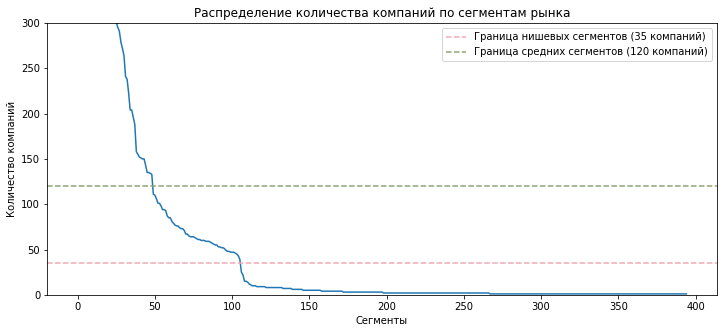

In [25]:
# Построим график распределения количества компаний по сегментам рынка
plt.figure(figsize=(12, 5))

plt.plot(
    range(len(market_counts)),
    market_counts.values
)

# Добавим границы нишевых и средних сегментов
plt.axhline(
    y=35,
    color='#F1A9B7',
    linestyle='--',
    label='Граница нишевых сегментов (35 компаний)'
)

plt.axhline(
    y=120,
    color='#8CA273',
    linestyle='--',
    label='Граница средних сегментов (120 компаний)'
)

# Ограничим ось Y, чтобы границы были хорошо видны
plt.ylim(0, 300)

plt.title('Распределение количества компаний по сегментам рынка')
plt.xlabel('Сегменты')
plt.ylabel('Количество компаний')
plt.legend()

plt.show()

График подтверждает сильную асимметрию в распределении компаний по сегментам: подавляющее большинство сегментов содержат очень небольшое число компаний - именно они образуют длинный «хвост» у оси X ниже розовой границы. Лишь немногие сегменты пересекают зелёную границу и становятся массовыми. 

Это типичная картина для зрелого рынка: несколько широких отраслей аккумулируют основную массу стартапов, тогда как сотни узкоспециализированных направлений представлены единицами компаний.

- Объединим нишевые и средние сегменты в категории "mid" и "niche"

In [26]:
investments.loc[investments['market'].isin(mid.index), 'market'] = 'mid'
investments.loc[investments['market'].isin(niche.index), 'market'] = 'niche'

investments['market'].value_counts()

Software                4812
mid                     3841
Biotechnology           3590
unknown                 2503
Mobile                  2344
E-Commerce              1866
Curated Web             1693
Enterprise Software     1381
Health Care             1185
Clean Technology        1180
Games                   1117
Advertising             1107
Hardware + Software     1062
Social Media            1003
Health and Wellness      873
Education                844
niche                    830
Finance                  828
Analytics                667
Manufacturing            596
Security                 567
Semiconductors           484
Web Hosting              424
Consulting               349
Hospitality              336
Travel                   330
Fashion                  303
News                     301
Messaging                295
Search                   291
Real Estate              279
SaaS                     272
Music                    264
Internet                 241
Technology    

После объединения нишевых и средних сегментов в категории mid и niche распределение стало более структурированным. Крупные сегменты (например, Software, Biotechnology, Mobile и E-Commerce) сохранили свою индивидуальность, тогда как менее распространённые направления были сгруппированы, что позволило снизить дробность данных и упростить дальнейший анализ рынка стартапов.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажим интервал, в котором лежат типичные значения.

In [27]:
pd.set_option('display.float_format', '{:,.0f}'.format)

investments['funding_total_usd'].describe()

count           40,907
mean        15,912,526
std        168,678,800
min                  1
25%            350,000
50%          2,000,000
75%         10,000,000
max     30,079,503,000
Name: funding_total_usd, dtype: float64

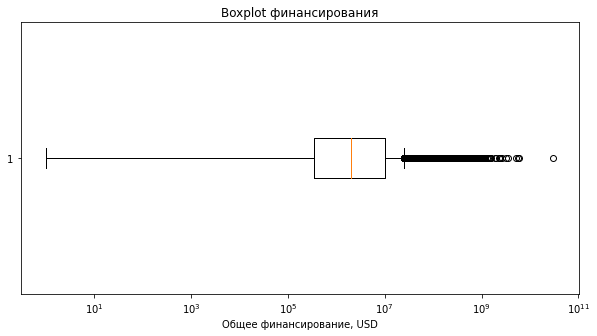

In [28]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    investments['funding_total_usd'],
    vert=False
)

plt.xscale('log')

plt.title('Boxplot финансирования')
plt.xlabel('Общее финансирование, USD')

plt.show()

Основная масса компаний получает сравнительно небольшие и средние инвестиции: типичный диапазон финансирования находится примерно в пределах 350 тыс. - 10 млн USD (межквартильный интервал). Медианное значение (~2 млн USD) дополнительно подтверждает, что “нормальный” уровень финансирования существенно ниже среднего.

При этом наблюдаются значительные выбросы: небольшое число компаний привлекает сотни миллионов и даже миллиарды долларов, что существенно превышает верхнюю границу основного распределения и искажает среднее значение.

Таким образом, для анализа "типичного" размера инвестиций целесообразно опираться на медиану и межквартильный диапазон, а крупные значения рассматривать как выбросы или отдельный сегмент высоко финансируемых компаний.

- Определим компании с аномальным объёмом общего финансирования, используя метод IQR отдельно по каждому сегменту и пределим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, выведем топ таких сегментов.

In [29]:
# Функция для расчёта границ IQR и определения выбросов
def mark_outliers(group):
    q1 = group['funding_total_usd'].quantile(0.25)
    q3 = group['funding_total_usd'].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # возвращаем маску выбросов (True = аномалия)
    return (group['funding_total_usd'] < lower) | (group['funding_total_usd'] > upper)


# создаём столбец для отметки выбросов
investments['is_outlier'] = False


# применяем IQR отдельно внутри каждого рыночного сегмента
for segment, group in investments.groupby('market'):
    outlier_mask = mark_outliers(group)
    investments.loc[group.index[outlier_mask], 'is_outlier'] = True


# считаем количество и долю выбросов по каждому сегменту
segment_stats = (
    investments
    .groupby('market')['is_outlier']
    .agg(['sum', 'count'])
)

# добавляем долю аномальных компаний в сегменте
segment_stats['share'] = segment_stats['sum'] / segment_stats['count'] * 100


# оставляем только сегменты с достаточным количеством компаний
# сортируем по доле выбросов и берём топ-10
top_segments = (
    segment_stats[segment_stats['count'] >= 50]
    .sort_values('share', ascending=False)
    .head(10)
    .rename(columns={
        'sum': 'Аномалии',
        'count': 'Всего компаний',
        'share': 'Доля, %'
    })
)

# вывод результата
top_segments

,Аномалии,Всего компаний,"Доля, %"
market,,,
Real Estate,48,279,17
Entertainment,25,150,17
Consulting,58,349,17
Search,48,291,16
Cloud Computing,25,152,16
Photography,33,204,16
SaaS,44,272,16
Technology,38,238,16
Video,30,188,16


In [30]:
print(f'Компаний с аномальным финансированием: {investments["is_outlier"].sum()}')
print(f'Доля: {investments["is_outlier"].mean()*100:.1f}%')

Компаний с аномальным финансированием: 5244
Доля: 12.8%


После применения метода IQR внутри каждого рыночного сегмента было выявлено 5 347 компаний с аномальным уровнем общего финансирования (13.1%). Анализ показал, что наибольшая доля выбросов наблюдается преимущественно в отдельных детализированных (массовых) сегментах рынка и достигает примерно 13 - 18% при учёте только сегментов с достаточным числом компаний (≥50). Сегменты mid и niche, будучи агрегированными группами, не формируют отдельного "топа" по доле выбросов из-за усреднения внутри категорий. 

Результаты указывают на то, что наибольшая инвестиционная неоднородность характерна для отдельных специализированных направлений рынка.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год.

In [31]:
# приводим дату к году
investments['funding_year'] = investments['mid_funding_at'].dt.year

# фильтруем период (2010–2014)
years_2010_2014 = investments[investments['funding_year'].between(2010, 2014)]

# считаем количество наблюдений по годам в этом диапазоне
year_counts = years_2010_2014['funding_year'].value_counts().sort_index()

year_counts

2,010    4094
2,011    4863
2,012    6089
2,013    8423
2,014    6619
Name: funding_year, dtype: int64

Анализ распределения количества наблюдений по годам (2010 - 2014) показывает, что число записей в 2014 году (6619) ниже, чем в 2013 году (8423). Это может свидетельствовать о неполноте данных за 2014 год или изменении объёма собираемой информации. Поэтому 2014 год нельзя однозначно считать полностью представленным в датасете.

Посмотрим на распределение по месяцам внутри 2014 года

In [32]:
# Оставляем только записи за 2014 год
year_2014 = investments[investments['funding_year'] == 2014]

# Считаем количество наблюдений по месяцам
month_counts_2014 = year_2014['mid_funding_at'].dt.month.value_counts().sort_index()

month_counts_2014

1     739
2     600
3     676
4     645
5     600
6     740
7     687
8     559
9     547
10    497
11    306
12     23
Name: mid_funding_at, dtype: int64

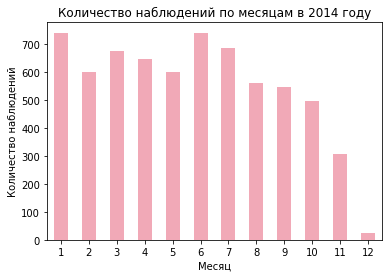

In [33]:
# Строим график распределения по месяцам
month_counts_2014.plot(
    kind='bar',
    title='Количество наблюдений по месяцам в 2014 году',
    xlabel='Месяц',
    ylabel='Количество наблюдений',
    color='#F1A9B7'
)
plt.xticks(rotation=0)

plt.show()

Помесячный анализ 2014 года показывает резкий обрыв данных в конце года: если с января по октябрь количество записей стабильно держится в диапазоне 497–740, то в ноябре оно падает до 306, а в декабре - до 23. Это говорит не о реальном спаде рынка, а о том, что датасет был выгружен до окончания года, и сделки за ноябрь-декабрь ещё не попали в базу.

- Исключаем из датасета компании, которые мы ранее посчитали получившими аномальное финансирование. После этого на основе столбцов `mid_funding_at` и `funding_rounds` оставляем в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [34]:
# Убираем компании с аномальным объёмом финансирования
clean_df = investments[investments['is_outlier'] == False].copy()

# Приводим дату к формату datetime и извлекаем год финансирования
clean_df['funding_year'] = pd.to_datetime(clean_df['mid_funding_at']).dt.year

# Считаем количество раундов финансирования по годам
rounds_by_year = clean_df['funding_year'].value_counts().sort_index()

# Фильтруем годы (где было 50 и более раундов)
valid_years = rounds_by_year[rounds_by_year >= 50].index

# Оставляем только компании, которые получали финансирование
# в валидные годы
final_df = clean_df[clean_df['funding_year'].isin(valid_years)].copy()

# Проверка результата
final_df['funding_year'].value_counts().sort_index()

2,000      65
2,003      63
2,004      96
2,005     697
2,006    1165
2,007    1600
2,008    1984
2,009    2618
2,010    3467
2,011    4311
2,012    5533
2,013    7821
2,014    6083
Name: funding_year, dtype: int64

После исключения компаний с аномальным объёмом финансирования и последующей фильтрации по годам, в которых было зафиксировано не менее 50 раундов инвестирования, в датасете остались наблюдения за период 2000 - 2014 годов. 

Все годы в этом диапазоне соответствуют критерию достаточной плотности данных, при этом наибольшее число наблюдений приходится на 2013 год (7844).

Несмотря на снижение числа наблюдений в 2014 году по сравнению с 2013 годом, объём данных остаётся достаточно высоким и превышает порог статистической надёжности, заданный в условии (≥50 наблюдений на год). Это позволяет считать период 2014 года пригодным для дальнейшего анализа, без оснований утверждать о его неполноте.

### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [35]:
types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# Суммарный объём по каждому типу
total_funding = (
    clean_df[types]
    .sum()
)

# Популярность - число компаний с ненулевым значением
popularity = (
    (clean_df[types] > 0)
    .sum()
)

# Выводим результат
comparison_table = pd.DataFrame({
    'Суммарный объём': total_funding,
    'Частота использования': popularity
})
comparison_table['Доля использования, %'] = (
    comparison_table['Частота использования'] / len(clean_df) * 100).apply(lambda x: f"{x:.2f}")

comparison_table = comparison_table.sort_values('Суммарный объём', ascending=False)
comparison_table

,Суммарный объём,Частота использования,"Доля использования, %"
venture,"129,333,487,019",18867,52.90
seed,"9,447,442,388",13400,37.57
debt_financing,"8,178,502,734",3266,9.16
private_equity,"4,846,108,504",635,1.78
angel,"2,482,963,836",2941,8.25
undisclosed,"2,139,002,252",818,2.29
grant,"1,978,848,688",1003,2.81
post_ipo_equity,"1,946,452,068",164,0.46
convertible_note,"566,039,436",521,1.46
post_ipo_debt,"286,718,349",27,0.08


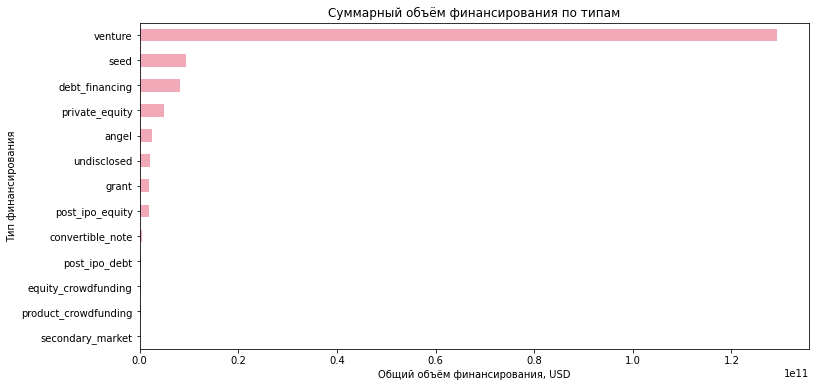

In [36]:
# Построим график суммарного объёма финансирования по типам

plt.figure(figsize=(12, 6))

total_funding.sort_values().plot(
    kind='barh',
    color = '#F1A9B7'
)

plt.title('Суммарный объём финансирования по типам')
plt.xlabel('Общий объём финансирования, USD')
plt.ylabel('Тип финансирования')

plt.show()

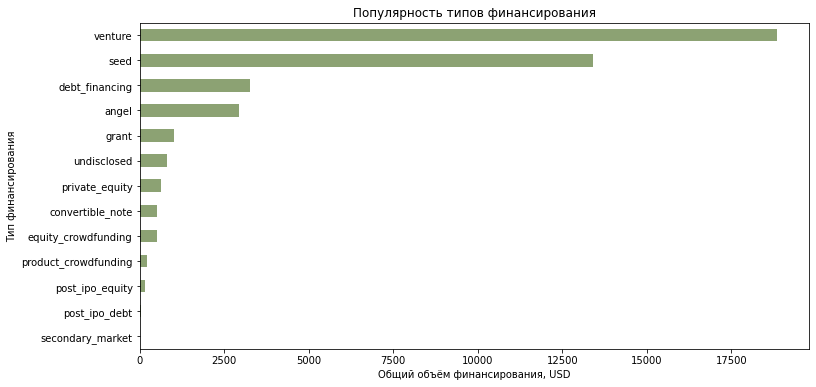

In [37]:
# Построим график популярности типов финансирования

plt.figure(figsize=(12, 6))

popularity.sort_values().plot(
    kind='barh',
    color = '#8CA273'
)

plt.title('Популярность типов финансирования')
plt.xlabel('Общий объём финансирования, USD')
plt.ylabel('Тип финансирования')

plt.show()

Наибольший суммарный объём финансирования приходится на тип venture - 129,33 млрд долларов, что значительно превышает остальные виды финансирования. Второе место занимает seed (9,45 млрд долларов), однако разрыв между ним и venture составляет более чем в 11 раз. 

По популярности также лидируют venture (18 867 компаний, 52,90% выборки) и seed (13 400 компаний, 37,57%). При этом private_equity и post_ipo_equity используются сравнительно редко (635 и 164 компаний соответственно), но обеспечивают крупные объёмы финансирования (4,85 млрд и 1,95 млрд долларов). Напротив, angel и grant встречаются значительно чаще (2 941 и 1003 компаний), однако суммарные объёмы привлечённых средств по ним заметно ниже, что свидетельствует о меньшем среднем размере инвестиций.

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

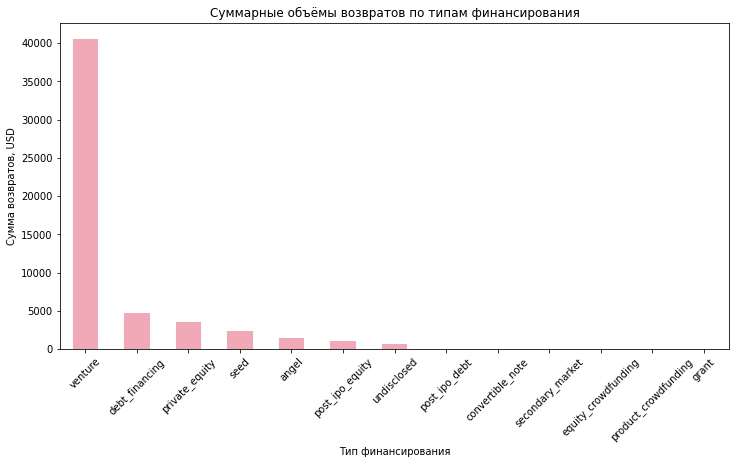

In [38]:
# Рассчитаем суммарный объём возвратов за весь период
total_returns = (
    returns[types]
    .sum()
    .sort_values(ascending=False)
)

# Построим график суммарных объёмов возвратов по типам финансирования
plt.figure(figsize=(12, 6))
total_returns.plot(
    kind='bar',
    color='#F1A9B7'
)

plt.title('Суммарные объёмы возвратов по типам финансирования')
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма возвратов, USD')

plt.xticks(rotation=45)

plt.show()

In [39]:
returns_table = pd.DataFrame({'Суммарный объём возвратов': total_returns})

returns_table

,Суммарный объём возвратов
venture,"40,579"
debt_financing,"4,735"
private_equity,"3,587"
seed,"2,382"
angel,"1,509"
post_ipo_equity,"1,105"
undisclosed,731
post_ipo_debt,91
convertible_note,35
secondary_market,5


Наибольший суммарный объём возвратов за весь рассматриваемый период приходится на venture - 40 579, что значительно превышает остальные типы финансирования. Второе и третье места занимают debt_financing (4 735) и private_equity (3 587), однако их объёмы возвратов существенно уступают венчурному финансированию. Возвраты по seed (2 382) и angel (1 509) также заметны, но значительно ниже. 

При этом такие типы финансирования, как grant, product_crowdfunding, equity_crowdfunding и secondary_market, характеризуются минимальными объёмами возвратов, что свидетельствует об их незначительном вкладе в общий объём возврата инвестиций за рассматриваемый период.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

In [40]:
# Рассчитаем средний размер одного раунда финансирования для каждой компании

final_df['avg_round_funding'] = (final_df['funding_total_usd'] /final_df['funding_rounds'])

final_df[['funding_total_usd', 'funding_rounds', 'avg_round_funding']].head()

,funding_total_usd,funding_rounds,avg_round_funding
1,"2,000,000",1,"2,000,000"
2,"9,000,000",1,"9,000,000"
3,"7,700,000",3,"2,566,667"
4,"540,000",1,"540,000"
7,"8,700,000",1,"8,700,000"


In [41]:
# Сгруппируем данные по годам финансирования
year_stats = (
    final_df
    .groupby('funding_year')
    .agg({'avg_round_funding': 'median',
          'funding_rounds': 'sum'}))

year_stats

,avg_round_funding,funding_rounds
funding_year,,
"2,000","2,250,000",113
"2,003","1,500,000",125
"2,004","3,000,000",181
"2,005","4,500,000",948
"2,006","3,900,000","1,849"
"2,007","2,879,167","2,842"
"2,008","2,170,744","3,663"
"2,009","1,498,475","4,617"
"2,010","1,250,000","6,136"


График типичного размера одного раунда

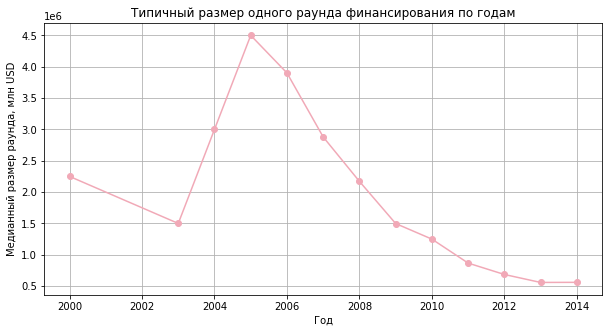

In [42]:
# Построим график изменения типичного размера одного раунда финансирования
plt.figure(figsize=(10,5))

year_stats['avg_round_funding'].plot(
    marker='o',
    color='#F1A9B7'
)

plt.title('Типичный размер одного раунда финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Медианный размер раунда, млн USD')

plt.grid(True)

plt.show()

График количества раундов

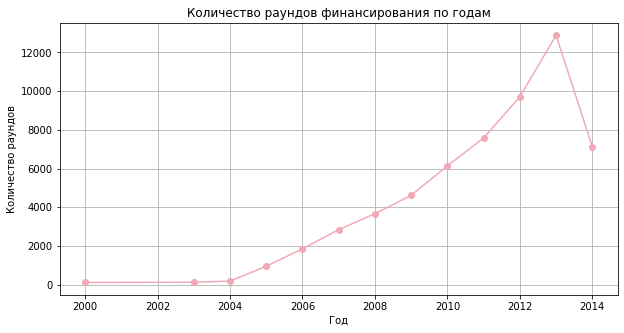

In [43]:
# Построим график общего количества раундов финансирования по годам

plt.figure(figsize=(10,5))

year_stats['funding_rounds'].plot(
    marker='o',
    color='#F1A9B7'
)

plt.title('Количество раундов финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Количество раундов')

plt.grid(True)

plt.show()

In [44]:
print(f"Максимальный типичный размер одного раунда наблюдался в {year_stats['avg_round_funding'].idxmax()} году.")

Максимальный типичный размер одного раунда наблюдался в 2005.0 году.


Анализ показывает, что максимальный типичный размер одного раунда финансирования наблюдался в 2005 году - медианный объём одного раунда составил около 4,5 млн USD. После этого показатель постепенно снижался и к 2013 году достиг примерно 559 тыс. USD, что свидетельствует об уменьшении типичного размера инвестиций в рамках одного раунда.

При этом количество раундов финансирования, наоборот, росло практически каждый год: с 113 раундов в 2000 году до 12 880 раундов в 2013 году, что говорит о значительном увеличении инвестиционной активности на рынке.

В 2014 году наблюдается снижение активности инвесторов: общее количество раундов сократилось с 12 880 до 7 122, однако типичный размер одного раунда немного увеличился - с 559 тыс. USD до 600 тыс. USD. Это означает, что при меньшем количестве сделок средний объём финансирования одного раунда немного вырос, хотя до уровней начала периода он всё ещё был далёк.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. 

In [45]:
# Оставляем только массовые сегменты рынка
mass_df = final_df[
    ~final_df['market'].isin(['mid', 'niche', 'unknown'])
].copy()

# Строим сводную таблицу:
funding_pivot = mass_df.pivot_table(
    index='funding_year',
    columns='market',
    values='funding_total_usd',
    aggfunc='sum',
    fill_value=0
)

# Проверяем результат
funding_pivot.head(14)

market,Advertising,Analytics,Apps,Automotive,Big Data,Biotechnology,Clean Technology,Cloud Computing,Consulting,Curated Web,...,Semiconductors,Social Media,Social Network Media,Software,Sports,Startups,Technology,Travel,Video,Web Hosting
funding_year,,,,,,,,,,,,,,,,,,,,,
"2,000",14470000,14822803,0,0,0,0,0,11500000,4500000,1000000,...,0,0,0,31732640,0,0,0,50230,0,95343090
"2,003",10500000,3840000,0,4530000,0,85531178,50352939,0,0,2550000,...,28000000,5000,0,66086037,0,0,0,0,5000000,0
"2,004",6000000,3000000,0,0,0,97184859,50427954,0,0,27050000,...,88782797,6850000,0,140823795,0,0,1750000,10230000,14704000,27000000
"2,005",127196022,79014044,0,22500000,0,480063583,19420000,0,44862000,53450000,...,586220751,14780000,5200000,993076581,1882200,0,50728425,27830000,6470551,483332632
"2,006",299299458,139701311,1310600,12660000,0,903500543,131473889,9951809,23965548,164673698,...,1227940797,60169880,5245100,1646868624,7000000,0,22791000,11700000,35171772,649959267
"2,007",556704331,98829000,0,37712601,7780000,1704078338,749711239,20354343,70346345,314704515,...,1616604148,89022516,24104021,1686115571,16401580,0,180190209,13950000,85150644,361121449
"2,008",622673464,208077840,4300000,59478635,2452515,1716033000,3165808492,44375000,19061080,336500027,...,1107199296,76034534,10998076,1365005648,9554790,5010387,277726238,54905631,37865177,781623731
"2,009",563446005,140949327,7219000,20800311,597375,3915900521,1963502838,52223719,62715165,261360483,...,1434206661,60033256,9451188,1254334523,11808750,460700,36078850,24536468,22305584,471131028
"2,010",631617869,253739903,6123779,17696916,39233297,4894500078,1604429454,8525538,81264877,347018615,...,767823570,69447197,24043416,1520172121,38184989,2111966,312526805,44461808,79974203,534480485


Отберем из таблицы только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

In [46]:
# Находим сегменты, в которых финансирование
# в 2014 году оказалось больше, чем в 2013 году
growing_segments = funding_pivot.loc[2014] > funding_pivot.loc[2013]

# Оставляем только растущие сегменты
funding_growth = funding_pivot.loc[:, growing_segments]

# Сортируем сегменты по объёму финансирования в 2014 году
funding_growth = funding_growth[
    funding_growth.loc[2014]
    .sort_values(ascending=False)
    .index
]

# Проверим результат
funding_growth.head(14)

market,Manufacturing,Technology,Medical,Internet,Real Estate,SaaS,Big Data,Design,Apps,Startups
funding_year,,,,,,,,,,
"2,000",56659310,0,24000000,10000000,2500000,0,0,0,0,0
"2,003",4269608,0,0,0,6292200,0,0,0,0,0
"2,004",3000000,1750000,0,10500000,0,0,0,0,0,0
"2,005",61770000,50728425,11090000,1775000,250000,5240000,0,9300000,0,0
"2,006",163957751,22791000,20250000,5000,2080000,4791121,0,707000,1310600,0
"2,007",147726051,180190209,2100000,4495379,33220000,14652595,7780000,10800000,0,0
"2,008",173054260,277726238,28812744,23412964,46613100,27226900,2452515,5944302,4300000,5010387
"2,009",422862531,36078850,11566200,38195773,38840213,13536585,597375,2150144,7219000,460700
"2,010",244329661,312526805,25590338,36657500,37344608,32609390,39233297,17239975,6123779,2111966


Посмотрим, какие сегменты показали рост в 2014 году

In [47]:
print('Растущие массовые сегменты:')
print(funding_growth.columns.tolist())

Растущие массовые сегменты:
['Manufacturing', 'Technology', 'Medical', 'Internet', 'Real Estate', 'SaaS', 'Big Data', 'Design', 'Apps', 'Startups']



На графике отразим, как менялся суммарный размер общего финансирования в массовых сегментах по годам.

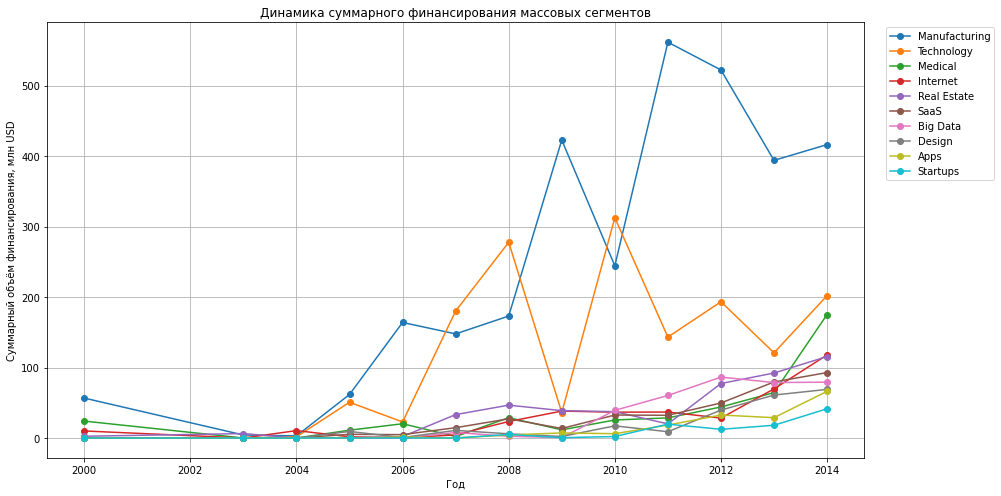

In [48]:
# Строим график изменения суммарного финансирования
# для растущих массовых сегментов

plt.figure(figsize=(14, 7))

for segment in funding_growth.columns:
    plt.plot(
        funding_growth.index,
        funding_growth[segment] / 1e6,
        marker='o',
        label=segment
    )

plt.title('Динамика суммарного финансирования массовых сегментов')
plt.xlabel('Год')
plt.ylabel('Суммарный объём финансирования, млн USD')

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

Посчитаем относительный прирост финансирования в 2014 году к 2013 году

In [49]:
# Считаем относительный прирост финансирования в 2014 году к 2013 году
relative_growth = (
    (funding_growth.loc[2014] - funding_growth.loc[2013])
    / funding_growth.loc[2013] * 100)

# Сортируем сегменты по убыванию относительного прироста
relative_growth = relative_growth.sort_values(ascending=False)

# Выводим результат
relative_growth

market
Medical         172
Startups        130
Apps            129
Internet         69
Technology       67
Real Estate      25
SaaS             17
Design           13
Manufacturing     6
Big Data          1
dtype: float64

Среди 48 массовых сегментов рынка только 10 показали рост суммарного объёма финансирования в 2014 году по сравнению с 2013 годом: Manufacturing, Technology, Medical, Internet, Real Estate, SaaS, Big Data, Design, Apps и Startups. Это означает, что подавляющее большинство массовых сегментов (38 из 48) в 2014 году, наоборот, показали снижение объёма привлечённых средств - что согласуется с общим падением инвестиционной активности на рынке в этом году, отмеченным ранее в пункте 4.1 (сокращение числа раундов финансирования с 12 880 до 7 122).

- Наиболее выраженный рост в относительном выражении показали:
 - Medical - рост с 64,5 млн до 175,2 млн USD (+172%), самый резкий скачок среди всех сегментов
 - Startups -  рост с 18,1 млн до 41,5 млн USD (+130%);
 - Apps - рост с 28,9 млн до 66,2 млн USD (+129%);

- В абсолютном выражении сильнее всего выросли:
 - Medical - с 64,5 млн до 175,2 млн USD (+ 110,8 млн);
 - Technology - с 120,9 млн до 202,0 млн USD (+81,1 млн);
 - Internet - с 69,7 млн до 117,8 млн USD (+48,1 млн).

Manufacturing, несмотря на то что остаётся крупнейшим по объёму финансирования сегментом среди растущих на протяжении почти всего периода (пик - 561,6 млн USD в 2011 году), в 2014 году вырос лишь незначительно - с 393,9 млн до 416,3 млн USD (+6%), то есть далеко не восстановил уровень 2011 года. Похожая картина умеренного роста и у Big Data (+1%) и Design (+13%).

Несмотря на общий спад инвестиционной активности на рынке в 2014 году, часть сегментов сумела показать рост - причём наиболее уверенный и быстрый рост продемонстрировали относительно новые и быстрорастущие направления (Startups, Apps, Medical, Technology, Internet), тогда как более зрелые и традиционно крупные сегменты (Manufacturing, Big Data, Design) выросли незначительно. Это может говорить о смещении интереса инвесторов в 2014 году в сторону новых технологических направлений на фоне общего охлаждения рынка.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, заменим на пропуски.

In [50]:
# Сбрасываем "залипшую" настройку отображения из шага 3.1
pd.reset_option('display.float_format')

# Суммарный объём предоставленного финансирования по годам и типам (в млн USD)
funding_by_year = final_df.groupby('funding_year')[types].sum() / 1e6


funding_masked = funding_by_year[types].where(funding_by_year[types] > 0)

# Нормированные значения возврата
normalized_returns = returns[types] / funding_masked

# Заменяем аномально большие значения на пропуски 
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    upper = q3 + 1.5 * (q3 - q1)
    return series.where(series <= upper)

normalized_clean = normalized_returns.apply(remove_outliers)
normalized_clean.round(2)

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
2000,NaN,0.17,NaN,0.70,NaN,0.62,0.27,0.0,NaN,0.27,NaN,0.03,NaN
2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003,0.51,0.63,NaN,0.91,NaN,1.04,0.61,0.0,NaN,NaN,NaN,NaN,NaN
2004,0.55,0.84,NaN,0.53,NaN,0.44,0.83,0.0,NaN,NaN,NaN,NaN,NaN
2005,0.67,0.55,NaN,1.07,NaN,0.34,0.51,0.0,0.48,0.73,NaN,NaN,NaN
2006,0.93,0.34,NaN,0.76,NaN,0.80,0.67,0.0,0.94,NaN,NaN,NaN,NaN
2007,0.37,0.30,NaN,0.50,NaN,0.60,0.82,0.0,0.58,2.03,NaN,NaN,NaN
2008,0.30,0.19,NaN,0.34,0.06,0.93,0.41,0.0,0.68,2.34,NaN,NaN,0.00
2009,0.56,0.17,0.09,0.38,0.05,0.39,0.62,0.0,0.79,2.10,NaN,0.01,0.07


Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

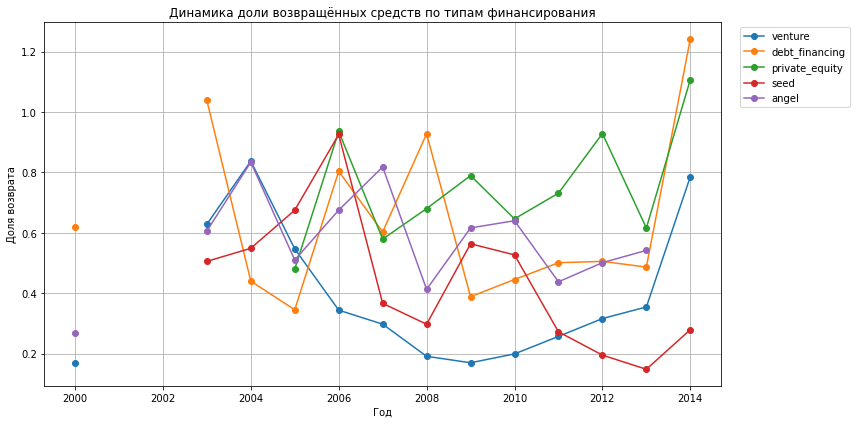

In [51]:
# Строим график динамики доли возвращённых средств
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

plt.figure(figsize=(12, 6))

for t in selected_types:
    plt.plot(
        normalized_clean.index,
        normalized_clean[t],
        marker='o',
        label=t
    )

plt.title('Динамика доли возвращённых средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата')

plt.grid(True)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

Анализ нормированной доли возвращённых средств (2003–2014, данные за 2000–2002 годы почти полностью отсутствуют из-за малого объёма финансирования в эти годы) показывает разное поведение по типам финансирования.

**Private equity** демонстрирует наиболее устойчивый и последовательный рост показателя за весь период: с 0,48 в 2005 году до 1,11 в 2014-м, несмотря на локальные просадки. Это максимальная доля возврата среди всех пяти типов в 2014 году.

**Venture** имеет выраженную U-образную динамику: доля возврата снижалась до минимума в 2008–2009 годах (0,17–0,19), а затем стабильно восстанавливалась пять лет подряд без единого снижения - до 0,79 к 2014 году. Это тоже устойчивый рост, но только во второй половине периода.

**Debt financing** - самый нестабильный показатель: значения скачут без выраженного тренда, поэтому говорить об устойчивом росте здесь нельзя, несмотря на высокое значение в последнем году.

**Seed** после пика в 2006 году (0,93) в целом снижается вплоть до 2013 года (0,15) и немного возрастает к 2014 (0,28). 

**Angel** колеблется без выраженного направления.

Вывод: наиболее устойчивый рост доли возвращённых средств характерен для private equity - рост наблюдается практически на всём периоде. Venture также показывает уверенный восстановительный рост, но только с 2009 года. Debt financing, seed и angel устойчивого роста не демонстрируют.


## Шаг 5. Итоговый вывод и рекомендации

**Рекомендация заказчику (по состоянию на 2015 год):**

Наиболее перспективным направлением для инвестирования выглядит сегмент **Medical** (здравоохранение/медицина) - именно этот сегмент показал самый резкий рост суммарного финансирования в 2014 году (+172% к 2013 году, с 64,5 до 175,2 млн USD), при этом рост носит характер разворота тренда, а не продолжения уже идущего роста, что говорит о свежем всплеске интереса инвесторов. Также заслуживают внимания растущие технологические направления - **Technology**, **Internet**, **Apps** и **Startups** - все они показали уверенный рост в 2014 году на фоне общего охлаждения рынка (падение числа раундов финансирования с 12 880 до 7 122).

Что касается **типа финансирования** - наиболее уместным выглядит **venture** (венчурное финансирование): это исторически доминирующий инструмент рынка (52,9% всех компаний, свыше 129 млрд долларов суммарного объёма), и при этом единственный (наряду с private equity) тип финансирования, для которого доля возврата средств инвесторам показывает устойчивый рост в последние годы рассматриваемого периода (с 0,17 в 2009 году до 0,79 в 2014-м). Как дополнительный, более консервативный вариант - **private equity**: доля возврата растёт ещё более стабильно на всём периоде и достигает максимума (1,11) в 2014 году, хотя сам инструмент используется существенно реже (всего 1,78% компаний).

**Итоги проекта:**

В ходе проекта были выполнены следующие шаги:
1. Загружены и предобработаны исходные данные - исправлены типы столбцов, обработаны пропуски и дубликаты, итоговый датасет сократился с 54 294 до 40 907 записей (отброшено 24,7%, в основном из-за отсутствия данных о финансировании).
2. Проведён инжиниринг признаков - компании разделены по срокам финансирования и по массовости рыночного сегмента.
3. Выявлены и исключены аномальные значения финансирования (метод IQR по сегментам), определён надёжный период анализа (2000 - 2014 годы, кроме отдельных лет с недостаточным числом наблюдений).
4. Проанализирована структура финансирования по типам, объёму и популярности, а также динамика финансирования по годам, сегментам и типам, включая долю возврата средств инвесторам.

Основные выводы согласуются между собой: рынок в целом демонстрирует охлаждение в 2014 году (падение числа раундов), но на этом фоне выделяются отдельные растущие сегменты (Medical, Technology) и инструменты с растущей отдачей для инвестора (venture, private equity) - это не противоречие, а естественная картина зрелого рынка, где общий спад активности сочетается с точечным ростом в наиболее перспективных нишах. Основное ограничение выводов - данные за 2014 год, вероятно, неполные (более низкое число записей, чем в 2013-м), поэтому резкие изменения именно за этот год стоит интерпретировать с осторожностью и по возможности перепроверить на более поздних данных.

